In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os, io
import json
import logging
from warnings import filterwarnings

from data.lucas_descriptions import data_gdf_description
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage, HuggingFaceLLMClient
from utils.llm_api.query import QueryProvider, QueryType
from utils.extraction import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)

## needed for running solution
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

filterwarnings("ignore")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
exec_needed_imports = """
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
"""

### Loading map of Europe

In [6]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[(world_gdf['EU_STAT'] == 'T') | (world_gdf['CNTR_ID'] == 'UK')]
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

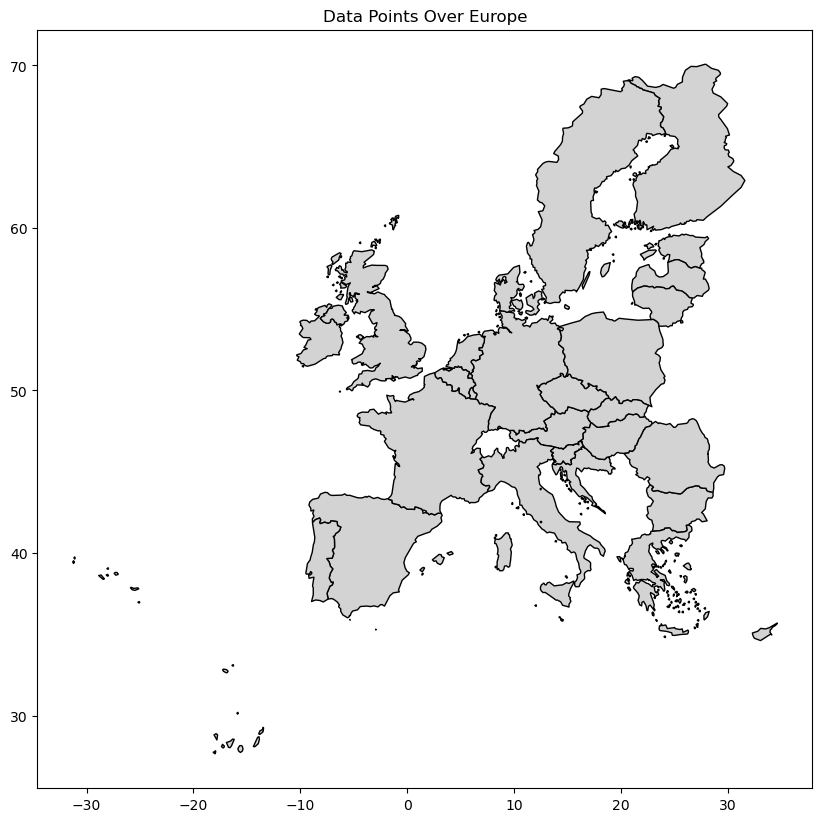

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

In [8]:
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

### LLM setup

In [9]:
llm_client = GPT4AllClient()

In [41]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [42]:
MODEL_NAME_INSTRUCTOR = available_models[0]
MODEL_NAME_CODER = available_models[0]

client_instructor = GPT4AllClient(model_name=MODEL_NAME_CODER)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [12]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

In [43]:
model_id = MODEL_NAME_CODER
BASE_QUERY_DIR = './data/user_query/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = f'./data/generated/{model_id}/'
BASE_METRICS_DIR = f'./data/metrics/{model_id}/'

In [44]:
def exec_solution(solution_function_string):
    if solution_function_string is None:
        print("No solution provided.")
        return
    
    local_scope = {}
    exec(
        exec_needed_imports + "\n" + \
        solution_function_string + "\n\n" + \
        "solve(data_gdf, europe_gdf)", 
        globals(), local_scope
    )

In [45]:
def run_test(objective: str):
    solution_function_string = None
    try:
        solution_function_string = run_pipeline(
            objective=objective,
            client_instructor=client_instructor,
            client_coder=client_coder,
            data_gdf=data_gdf,
            data_gdf_description=data_gdf_description,
            europe_gdf=europe_gdf,
            europe_gdf_description=europe_gdf_description,
            retry_count=3
        )
    except Exception as e:
        logging.error(e)
        
    if solution_function_string is None:
        try:
            solution_function_string = run_pipeline(
                objective=objective,
                client_instructor=client_instructor,
                client_coder=client_coder,
                data_gdf=data_gdf,
                data_gdf_description=data_gdf_description,
                europe_gdf=europe_gdf,
                europe_gdf_description=europe_gdf_description,
                retry_count=1
            )
        except Exception as e:
            logging.error(e)
            
    return solution_function_string
    

# 1. query

In [13]:
objective = "Plot on the map all the points that have pH_CaCl2 > 6. Use geopandas. Save the image as a png."

2025-01-30 14:02:35,209 - Query finished successfully, response: 
```python
# Filter the data to include only points with pH_CaCl2 > 6.0
transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6.0]

# Save the transformed GeoDataFrame as a new object called 'filtered_points'
filtered_points = transformed_gdf.copy()

# Import geopandas to plot points on a map
import geopandas as gpd

# Create an empty GeoSeries from the filtered data, with geometry column set as the CRS (coordinate reference system)
crs = {'init': 'epsg:4326'}
geometry_series = gpd.points_from_xy(filtered_points['TH_LONG'], filtered_points['TH_LAT'])

# Convert to a GeoDataFrame
filtered_gdf = gpd.GeoDataFrame(geometry=geometry_series, crs=crs)

# Plot the points on a map (this will be done in another step)
```
2025-01-30 14:02:37,474 - Query finished successfully, response: 
map
2025-01-30 14:02:47,052 - Query finished successfully, response: 
Here is the code to generate a map-based visualization by overlaying data from 'tr

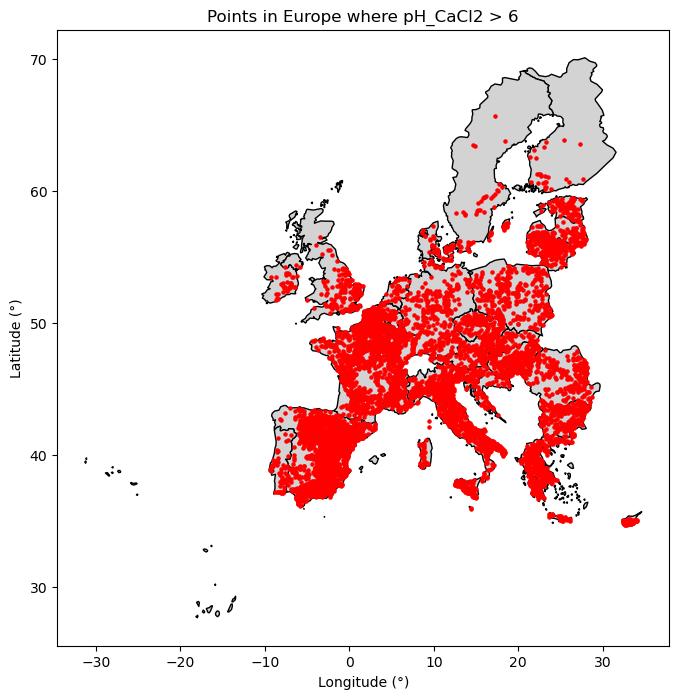

In [14]:
solution_function_string = run_test(objective)

In [15]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only points with pH_CaCl2 > 6.0
	transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6.0]
	# Save the transformed GeoDataFrame as a new object called 'filtered_points'
	filtered_points = transformed_gdf.copy()
	# Import geopandas to plot points on a map
	# Create an empty GeoSeries from the filtered data, with geometry column set as the CRS (coordinate reference system)
	crs = {'init': 'epsg:4326'}
	geometry_series = gpd.points_from_xy(filtered_points['TH_LONG'], filtered_points['TH_LAT'])
	# Convert to a GeoDataFrame
	filtered_gdf = gpd.GeoDataFrame(geometry=geometry_series, crs=crs)
	# Plot the points on a map (this will be done in another step)
	# Create figure and axis objects for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set europe_gdf as the base map with black edges and light gray fill color
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Overlay data from

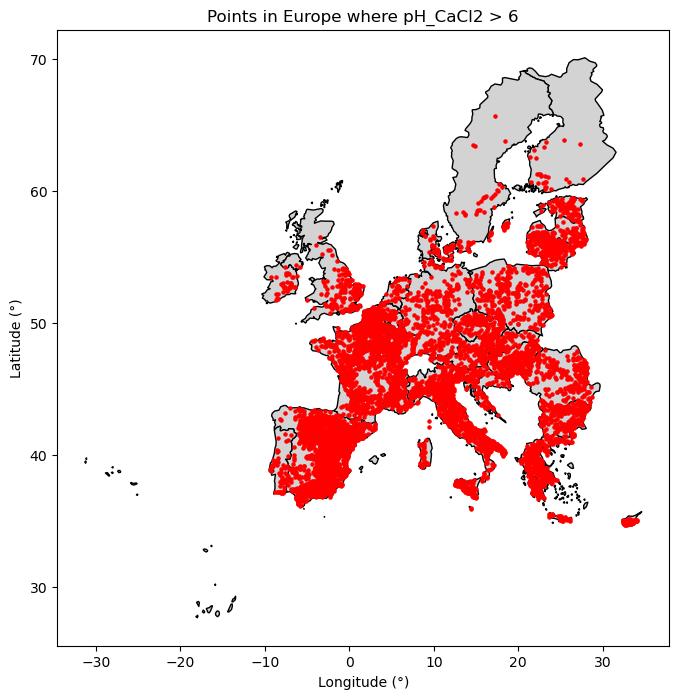

In [16]:
exec_solution(solution_function_string)

# 2. query

In [17]:
print()

In [18]:
objective = "Plot on the map all the points with LC0_Desc=Woodland in Europe. Save the result as a png. Use geopandas."

2025-01-30 14:02:53,143 - Query finished successfully, response: 
```python
# Filter the data for LC0_Desc=Woodland in Europe
transformed_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Save the result as a GeoDataFrame with only the required columns
required_columns = ['geometry', 'POINTID', 'Depth', 'TH_LAT', 'TH_LONG']
transformed_gdf = transformed_gdf[required_columns]
```
2025-01-30 14:02:55,290 - Query finished successfully, response: 
map
2025-01-30 14:03:03,350 - Query finished successfully, response: 
Here is the code to generate a map-based visualization by overlaying data from 'transformed_gdf' on a map of Europe:
```python
import matplotlib.pyplot as plt

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the base map of Europe
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Overlay data from 'transformed_gdf' on the map
ax.scatter(transformed_gdf['TH_LAT'], transformed_gdf['TH_LONG'],
          c=transformed_gdf['LC0_Desc

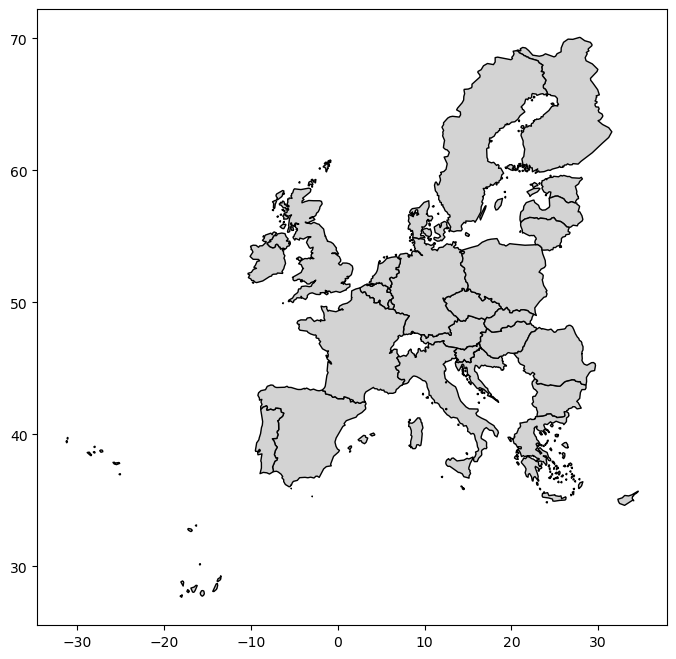

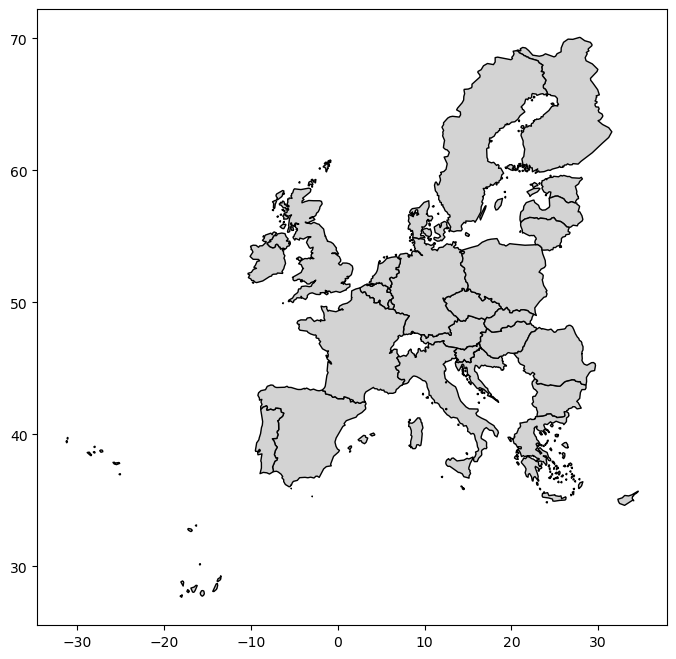

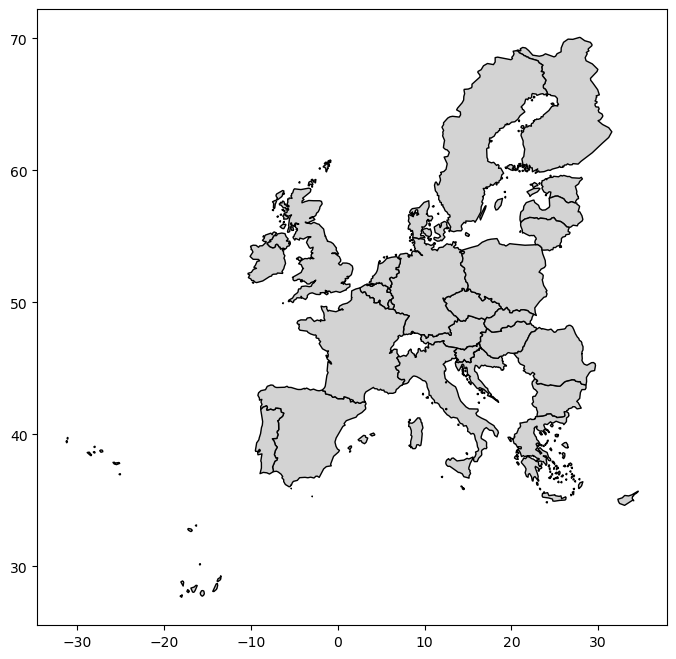

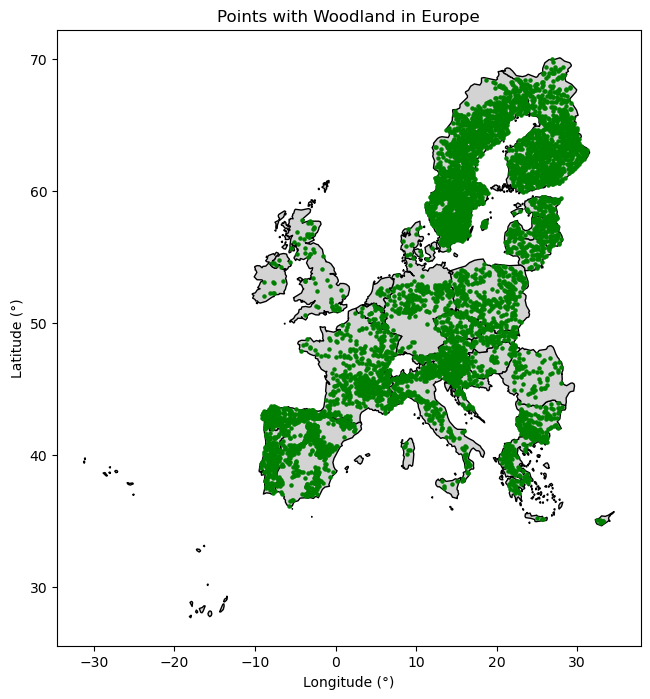

In [19]:
solution_function_string = run_test(objective)

In [20]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only points with LC0_Desc=Woodland in Europe
	transformed_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
	# Save the result as a GeoDataFrame called 'woodlands'
	woodlands = transformed_gdf.copy()
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter 'transformed_gdf' to only include points with LC0_Desc=Woodland and plot them on top of the European map
	transformed_gdf[transformed_gdf['LC0_Desc'] == 'Woodland'].plot(ax=ax, marker='o', markersize=5, color='green')
	# Set the title and labels for better visualization
	ax.set_title('Points with Woodland in Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	# Save the plot as a PNG file
	plt.savefig('woodland_points_europe.png', bbox_inches='tight')


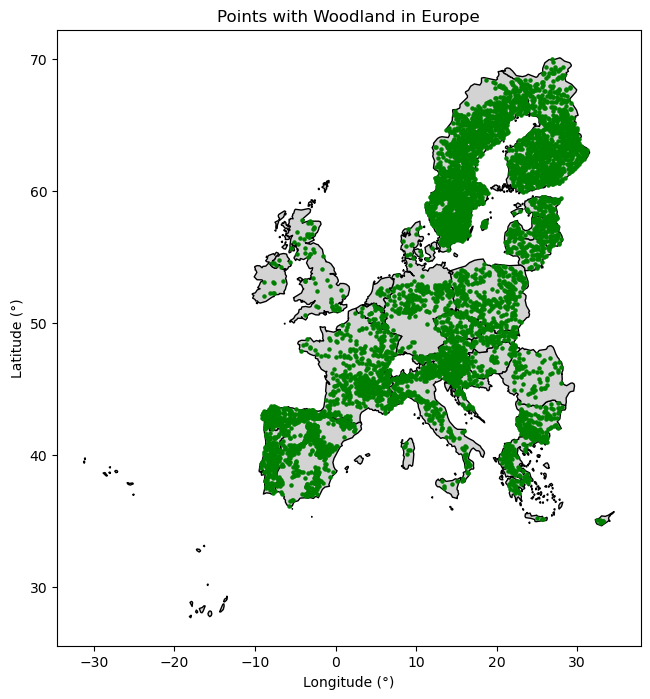

In [21]:
exec_solution(solution_function_string)

# 3. query

In [22]:
objective = "Plot on the map all the points with LC0_Desc=Woodland & pH<6 in Europe. Save the result as a png. Use geopandas."

2025-01-30 14:03:41,671 - Query finished successfully, response: 
```python
# Filter the data for LC0_Desc=Woodland & pH<6 in Europe
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
```

Note: The above code block filters the GeoDataFrame `data_gdf` to include only rows where the value in column `'LC0_Desc'` is equal to `'Woodland'` and the value in column `'pH_H2O'` is less than 6. This will create a new GeoDataFrame called `transformed_gdf`.
2025-01-30 14:03:43,893 - Query finished successfully, response: 
map
2025-01-30 14:03:51,321 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the map of Europe as the base layer using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter 'transformed_gdf' to include only points with LC0_Desc=Woodland & pH<6
woodland_points = transformed_gdf[(transf

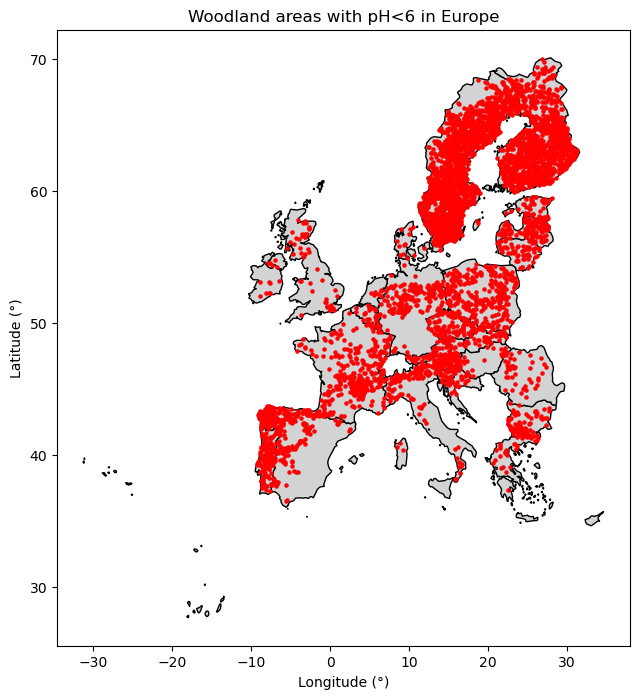

In [23]:
solution_function_string = run_test(objective)

In [24]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data for LC0_Desc=Woodland & pH<6 in Europe
	transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the map of Europe as the base layer using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter 'transformed_gdf' to include only points with LC0_Desc=Woodland & pH<6
	woodland_points = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed_gdf['pH_H2O'] < 6)]
	# Plot the filtered data locations on top of the map
	woodland_points.plot(ax=ax, marker='o', markersize=5, color='red')
	# Set the title and labels for better visualization
	ax.set_title('Woodland areas with pH<6 in Europe')
	ax.set_xlabel('Longitude (°)')
	ax.set_ylabel('Latitude (°)')
	# Show the plot as a PNG image file
	plt.savefig('woodland_pH_less_than_6.png', bbo

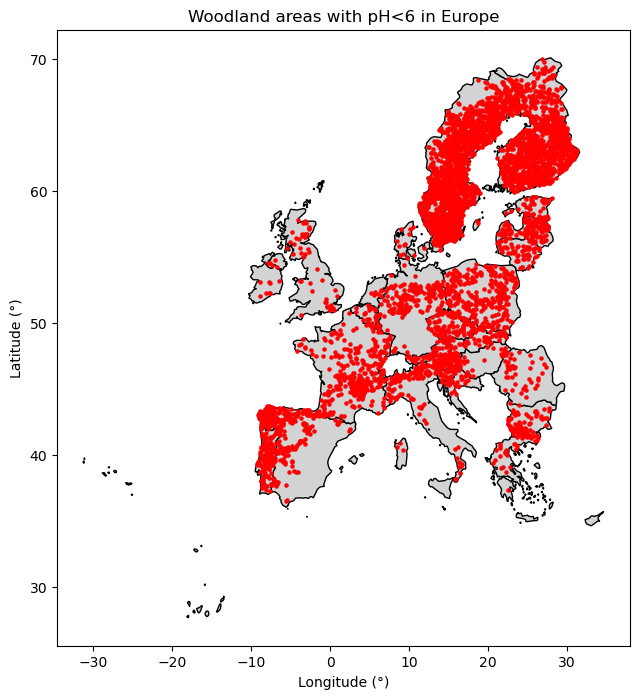

In [25]:
exec_solution(solution_function_string)

# 4. query

In [26]:
objective = "Perform KMeans clustering on the TH_LAT and TH_LONG data to identify 3 clusters and plot them on a map. Save it as a png."

2025-01-30 14:03:58,063 - Query finished successfully, response: 
```python
# Import necessary packages
import pandas as pd
from sklearn.cluster import KMeans

# Filter the data to include only rows where Depth is not missing and NUTS_0 is 'EU'
transformed_gdf = data_gdf[data_gdf['Depth'].notna() & (data_gdf['NUTS_0'] == 'EU')]

# Select relevant columns for clustering
cluster_data = transformed_gdf[['TH_LAT', 'TH_LONG']]
kmeans = KMeans(n_clusters=3)
kmeans.fit(cluster_data)

transformed_gdf['Cluster'] = kmeans.predict(cluster_data)
```
2025-01-30 14:03:58,069 - Error while running transform query: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by KMeans.
2025-01-30 14:04:03,192 - Query finished successfully, response: 
```python
# Import necessary packages
import pandas as pd
from sklearn.cluster import KMeans

# Filter the data to include only rows where Depth is not missing and NUTS_0 is 'EU'
transformed_gdf = data_gdf[data_gdf['Depth'].notna() & (data

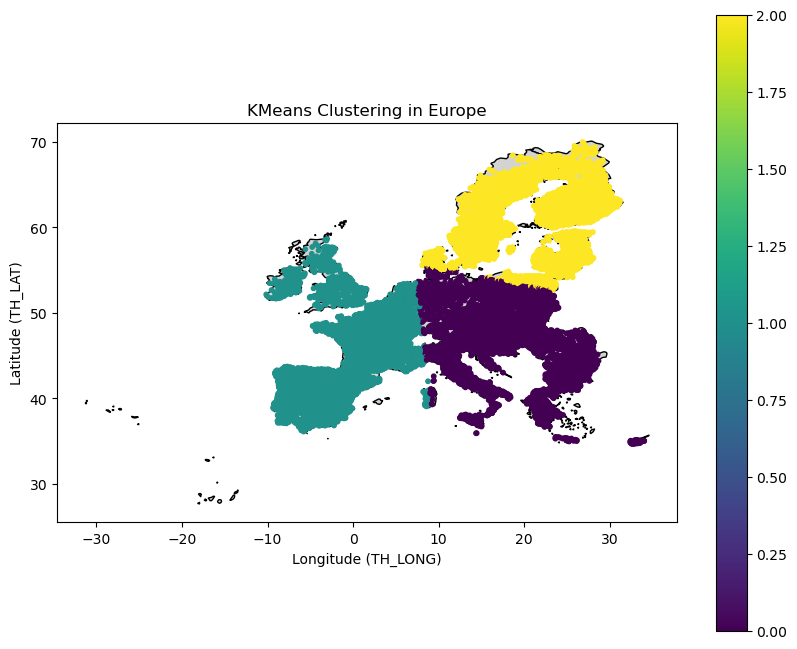

In [27]:
solution_function_string = run_test(objective)

In [28]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary packages
	# Select columns of interest for clustering (TH_LAT and TH_LONG)
	data_gdf = data_gdf[['TH_LAT', 'TH_LONG']]
	# Scale the latitude and longitude values to a common range (0-1) using Min-Max Scaler from scikit-learn
	scaler = MinMaxScaler()
	scaled_data = scaler.fit_transform(data_gdf)
	# Perform KMeans clustering with 3 clusters on scaled data
	kmeans = KMeans(n_clusters=3)
	cluster_labels = kmeans.fit_predict(scaled_data)
	# Create a new GeoDataFrame 'transformed_gdf' to store the transformed results
	transformed_gdf = pd.DataFrame({'TH_LAT': data_gdf['TH_LAT'], 
	                                'TH_LONG': data_gdf['TH_LONG'],
	                                'cluster_labels': cluster_labels})
	# Convert the new GeoDataFrame back into a GeoSeries for spatial operations (not necessary in this case)
	transformed_gdf = gpd.GeoDataFrame(transformed_gdf, geometry=gpd.points_from_xy(transforme

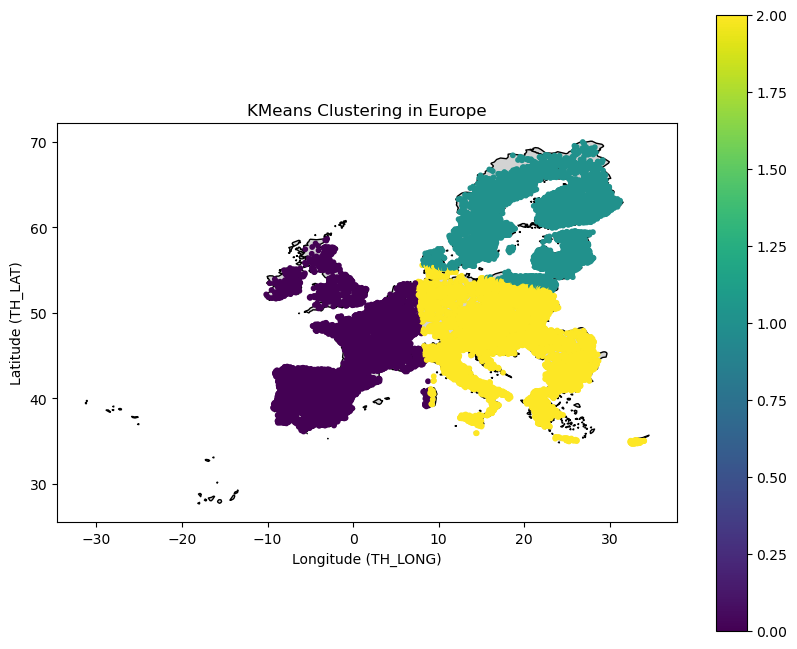

In [29]:
exec_solution(solution_function_string)

# 5. query

In [30]:
objective = "Create a map with markers for all locations where 'K' is above its median value, in Europe. Use geopandas. Save the result as a png."

2025-01-30 14:04:38,057 - Query finished successfully, response: 
```python
# Import necessary packages
import geopandas as gpd

# Calculate the median of K values in data_gdf
median_K = stats.median(data_gdf['K'])

# Filter data_gdf to include only rows where 'K' is above its median value
data_gdf_above_median_k = data_gdf[data_gdf['K'] > median_K]

# Create a new GeoDataFrame with the filtered data and save it as transformed_gdf
transformed_gdf = gpd.GeoDataFrame(data_gdf_above_median_k)

# Save the result to a PNG file (this will not be executed, just shown in code)
# transformed_gdf.to_file('k_above_median.png', driver='PNG')
```
2025-01-30 14:04:38,058 - Error while running transform query: name 'stats' is not defined
2025-01-30 14:04:42,964 - Query finished successfully, response: 
```python
import geopandas as gpd
from scipy import stats

# Calculate the median of K values in data_gdf
median_K = stats.median(data_gdf['K'])

# Filter data_gdf to include only rows where 'K' is abo

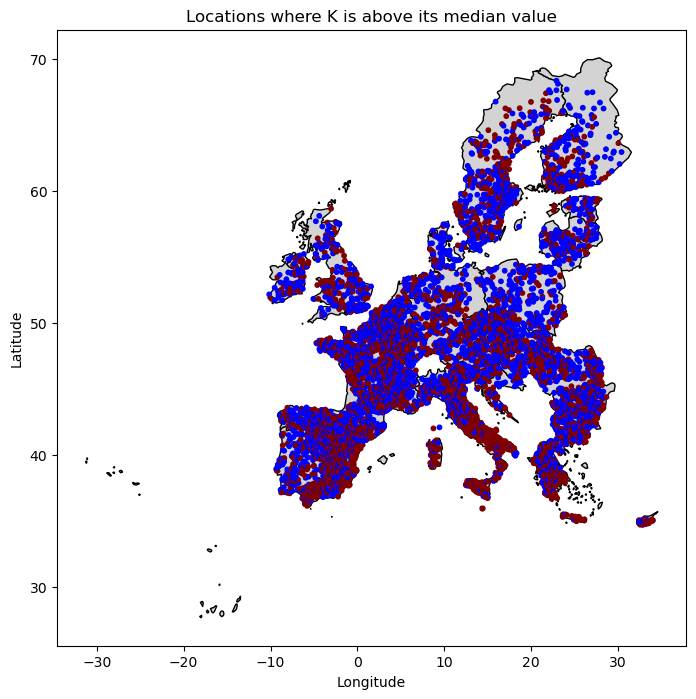

In [31]:
solution_function_string = run_test(objective)

In [32]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary packages
	# Filter data where K is above its median value
	median_K = data_gdf['K'].median()
	transformed_gdf = data_gdf[data_gdf['K'] > median_K]
	# Create a new GeoDataFrame with only the filtered rows and required columns
	required_columns = ['geometry', 'POINTID', 'pH_CaCl2', 'pH_H2O', 'EC', 
	                   'OC', 'CaCO3', 'P', 'N', 'K']
	transformed_gdf = transformed_gdf[required_columns]
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the map of Europe as the base layer
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Overlay data from 'transformed_gdf' on top of the map
	ax.scatter(x=transformed_gdf.geometry.x, y=transformed_gdf.geometry.y,
	           c=[(0.5, 0, 0) if val > transformed_gdf['K'].median() else (0, 0, 1)
	              for val in transformed_gdf['K']], s=10)
	# Set the title and labels
	ax.set_title('Location

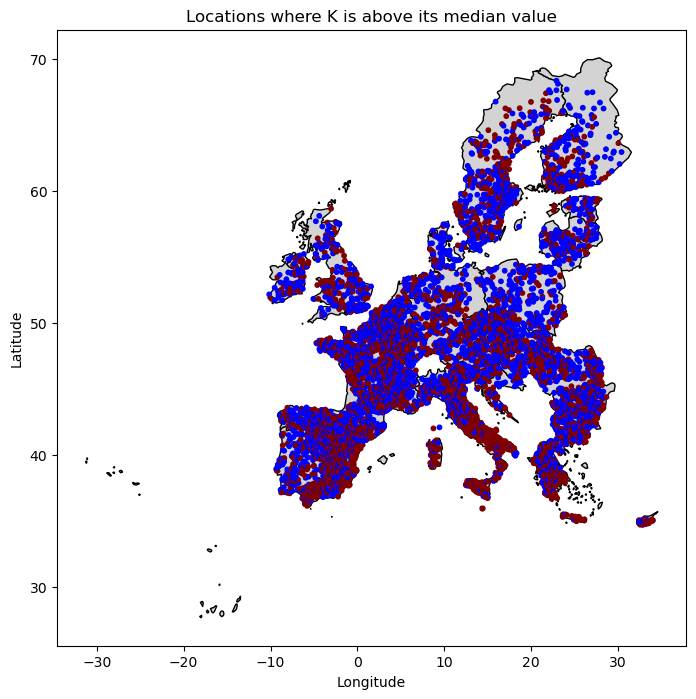

In [33]:
exec_solution(solution_function_string)

# 6. query

In [34]:
objective = "Generate a heatmap where each point is weighted by 'pH_CaCl2', in Europe. Don't merge these shapefiles just plot them. Use geopandas. Save the result as a png."

2025-01-30 14:05:11,395 - Query finished successfully, response: 
```python
# Filter the data to include only points in Europe (NUTS_0 == 'Europe')
transformed_gdf = data_gdf[data_gdf['NUTS_0'] == 'Europe']

# Select relevant columns for transformation and plotting
selected_columns = ['geometry', 'pH_CaCl2']
transformed_gdf = transformed_gdf[selected_columns]

# Create a new column to weight the points by pH_CaCl2 value
transformed_gdf['weight'] = transformed_gdf['pH_CaCl2']

# Save the result as a GeoDataFrame for plotting with geopandas
import geopandas as gpd

# Convert the GeoDataFrame to a spatial DataFrame (GeoSeries) and plot it using geopandas
gdf_series = gpd.GeoSeries(transformed_gdf['geometry'])
gdf_series.plot(column='weight', legend=True, cmap='hot')
```
2025-01-30 14:05:11,407 - Error while running transform query: aspect must be finite and positive 
2025-01-30 14:05:18,257 - Query finished successfully, response: 
```python
# Filter the data to include only points in Eur

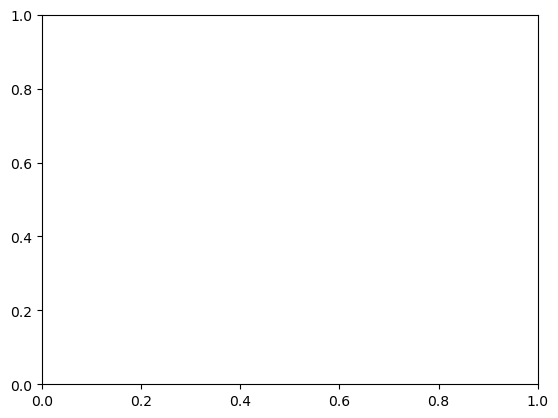

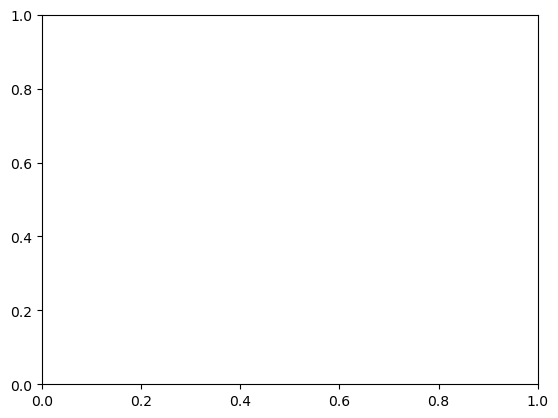

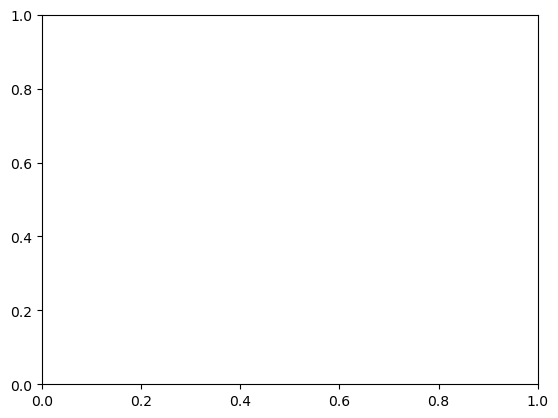

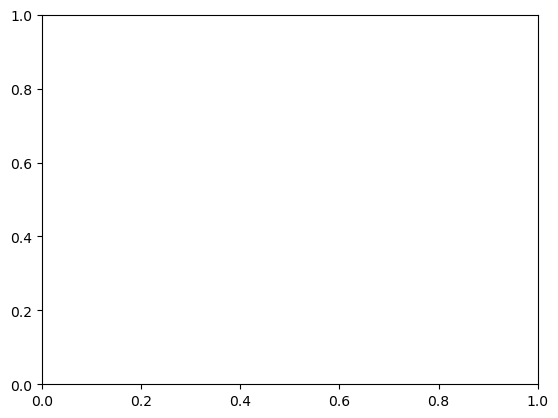

In [35]:
solution_function_string = run_test(objective)

In [36]:
print(solution_function_string)

None


In [39]:
exec_solution(solution_function_string)

No solution provided.


# 7. query

In [40]:
objective = "Create a map with markers for points where 'K' is in the top 10 percentile, in Europe. Don't merge these shapefiles just plot them. Use geopandas. Save the result as a png."

2025-01-30 14:06:14,046 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter the data to include only points where 'K' is in the top 10 percentile
top_10_percentile = data_gdf['K'].quantile(0.9)
filtered_data = data_gdf[data_gdf['K'] > top_10_percentile]

# Create a new GeoDataFrame for the filtered data
transformed_gdf = gpd.GeoDataFrame(filtered_data, geometry='geometry')

# Save the result as a png file (without visualizing or printing anything)
transformed_gdf.to_file('top_10_percentile_K_points.shp', driver='ESRI Shapefile')
```
2025-01-30 14:06:14,058 - Error while running transform query: ESRI Shapefile does not support datetime fields
2025-01-30 14:06:18,858 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter the data to include only points where 'K' is in the top 10 percentile
top_10_percentile = data_gdf['K'].quantile(0.9)
filtered_data = data_gdf[data_gdf['K'] > top_10_percentile]

# Create a new GeoDataFrame

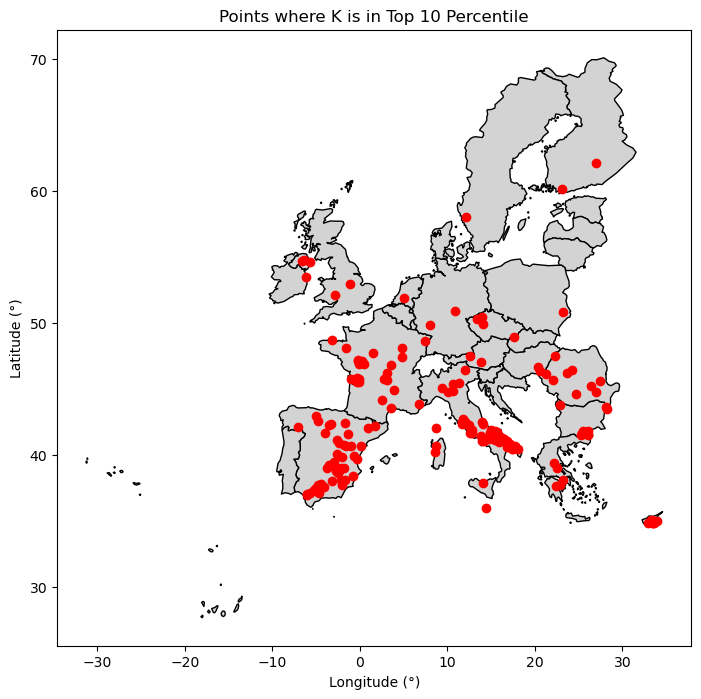

In [41]:
solution_function_string = run_test(objective)

In [42]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only points where 'K' is in the top 10 percentile
	top_10_percentile = data_gdf['K'].quantile(0.9)
	filtered_data = data_gdf[data_gdf['K'] > top_10_percentile]
	# Create a new GeoDataFrame for the filtered data, dropping datetime fields
	transformed_gdf = gpd.GeoDataFrame(filtered_data.drop(['SURVEY_DATE'], axis=1), geometry='geometry')
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the map of Europe as the base layer using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Get the top 10 percentile values from 'K' column in transformed_gdf
	top_10_percentile_K = transformed_gdf['K'].quantile(0.9)
	# Filter points where K is greater than or equal to the top 10 percentile value
	filtered_points = transformed_gdf[transformed_gdf['K'] >= top_10_percentile_K]
	# Plot markers for these filtered points on the map
	filtere

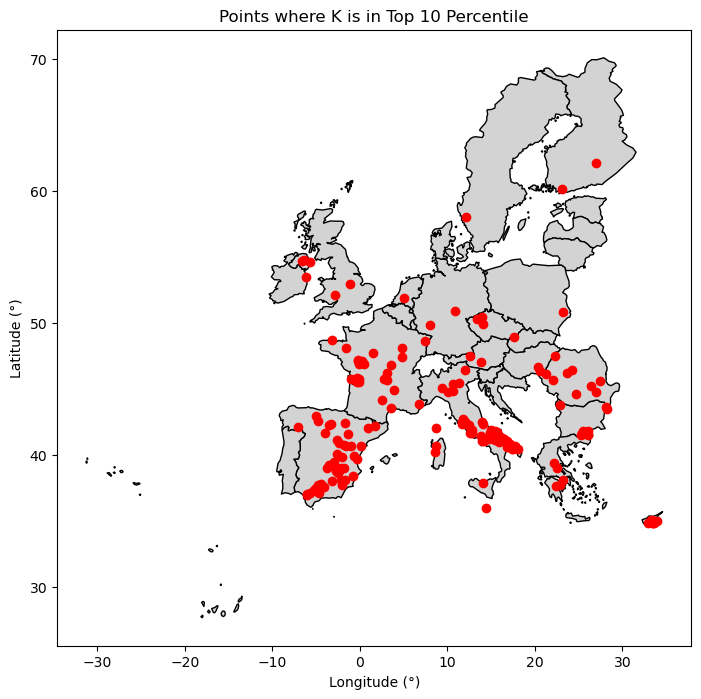

In [43]:
exec_solution(solution_function_string)

# 8. query

In [44]:
objective = "Plot on the map and colour differently points with 'pH_H2O'>5 and 'pH_H2O'<5 in Europe."

In [45]:
solution_function_string = run_test(objective)

2025-01-30 14:06:40,452 - Query finished successfully, response: 
```python
# Filter points with pH_H2O > 5 and < 5 in Europe
transformed_gdf = data_gdf.copy()
filtered_points_high_pH = transformed_gdf[(transformed_gdf['pH_H2O'] > 5)]
filtered_points_low_pH = transformed_gdf[(transformed_gdf['pH_H2O'] < 5)]

# Create two separate GeoDataFrames for high and low pH points
high_pH_gdf = filtered_points_high_pH.copy()
low_pH_gdf = filtered_points_low_pH.copy()

# Color differently the points with 'pH_H2O'>5 and 'pH_H2O'<5 in Europe
from folium import Map, Point

map_europe = Map(location=[52.2167, 11.5167], zoom_start=4)

high_pH_points = []
low_pH_points = []

for index, row in high_pH_gdf.iterrows():
    point = Point(row['TH_LAT'], row['TH_LONG'])
    high_pH_points.append(point)
    
for index, row in low_pH_gdf.iterrows():
    point = Point(row['TH_LAT'], row['TH_LONG'])
    low_pH_points.append(point)

high_pH_map = Map(location=[52.2167, 11.5167], zoom_start=4)
low_pH_map = Map(loca

In [46]:
print(solution_function_string)

None


In [47]:
exec_solution(solution_function_string)

No solution provided.


# 9. query

In [48]:
objective = "Create a map displaying the distribution of soil types ('LC0_Desc') across Europe. Each soil type should be represented by a different color. Use geopandas and save the map as a png."

In [49]:
solution_function_string = run_test(objective)

2025-01-30 14:07:19,200 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter the data to only include rows where LC0_Desc is not null and Depth is '10_20'
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'].notnull()) & (data_gdf['Depth'] == '10_20')]

# Group by LC0_Desc and count the number of occurrences
soil_counts = transformed_gdf.groupby('LC0_Desc')['geometry'].count().reset_index()

# Merge soil counts with a new GeoDataFrame containing unique values from LC0_Desc column
transformed_gdf = gpd.merge(transformed_gdf, soil_counts, on='LC0_Desc', how='left')

# Create a dictionary to map each LC0_Desc value to a color
color_map = {value: i for i, value in enumerate(soil_counts['geometry'].unique())}

# Map the colors based on the count of occurrences and save as png
transformed_gdf['LC0_Color'] = transformed_gdf.apply(lambda row: color_map[row['LC0_Desc']], axis=1)
gpd.GeoSeries(transformed_gdf).plot(column='LC0_Color', legend=True, cmap='viridis')
```

In [50]:
print(solution_function_string)

None


In [51]:
exec_solution(solution_function_string)

No solution provided.


# 10. query

In [52]:
objective = "Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20. Use geopandas and save the map as a png."

2025-01-30 14:07:50,192 - Query finished successfully, response: 
```python
# Import necessary libraries
import geopandas as gpd

# Filter data for LC0_Desc='Grassland' and LC0_Desc='Woodland'
filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]

# Filter points where OC > 20
filtered_points = filtered_gdf[filtered_gdf['OC'] > 20]

# Create a new GeoDataFrame for the transformed data
transformed_gdf = gpd.GeoDataFrame(filtered_points, geometry='geometry')
```
2025-01-30 14:07:52,386 - Query finished successfully, response: 
map
2025-01-30 14:08:00,550 - Query finished successfully, response: 
```python
import geopandas as gpd

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter 'transformed_gdf' to include only LC0_Desc='Grassland' and LC0_Desc='Woodland'
filtered_gdf = transformed_gdf[(

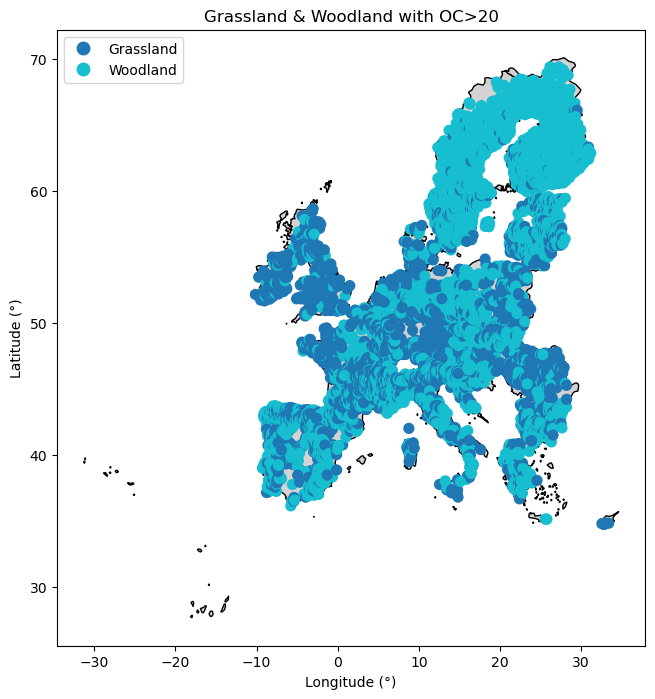

In [53]:
solution_function_string = run_test(objective)

In [54]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	# Filter data for LC0_Desc='Grassland' and LC0_Desc='Woodland'
	filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
	# Filter points where OC > 20
	filtered_points = filtered_gdf[filtered_gdf['OC'] > 20]
	# Create a new GeoDataFrame for the transformed data
	transformed_gdf = gpd.GeoDataFrame(filtered_points, geometry='geometry')
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter 'transformed_gdf' to include only LC0_Desc='Grassland' and LC0_Desc='Woodland'
	filtered_gdf = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
	# Filter the data further based on OC > 20
	filtered_gdf = filtered_gdf[filtered_gdf['OC'] > 20]
	# Plot t

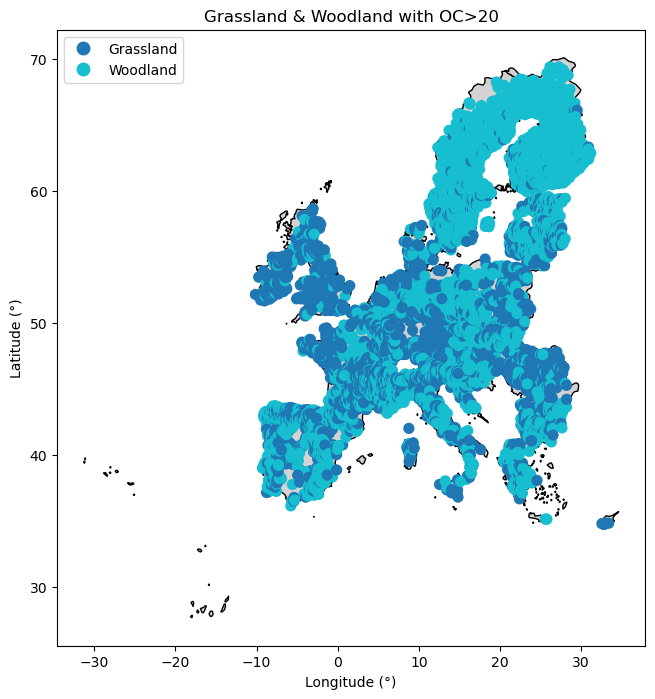

In [55]:
exec_solution(solution_function_string)

In [56]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

### Testing on all queries

In [ ]:
for query_type in ['geo']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        print(query)
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = run_test(query)
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, generated_result)
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)

Processing 10 geo queries
Plot all the points that have pH_CaCl2 > 6. use geopandas. save the image as a png.


2025-01-31 09:37:04,714 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with pH_CaCl2 > 6
filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Plot the filtered GeoDataFrame using geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_gdf.plot(ax=ax)
plt.title('Points with pH_CaCl2 > 6')
plt.savefig('pH_CaCl2_filtered_points.png')

# Ensure the code is concise and valid, leveraging the appropriate packages listed above.
```
2025-01-31 09:37:05,102 - Error while running transform query: name 'transformed_gdf' is not defined
2025-01-31 09:37:14,634 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with pH_CaCl2 > 6
filtered_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Plot the filtered GeoDataFrame using geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_gdf.plot(ax=ax)
plt.title('Points with pH_CaCl2 > 6')


Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20. Use geopandas and save the map as a png.


2025-01-31 09:37:59,092 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with LC0_Desc='Grassland' and 'OC'>20, or LC0_Desc='Woodland' and 'OC'>20
filtered_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') & (data_gdf['OC'] > 20) | 
                        (data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['OC'] > 20)]

# Plot the filtered GeoDataFrame using geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_gdf.plot(ax=ax)
plt.title('Grassland and Woodland points with OC>20')
plt.savefig('grassland_woodland_filtered_points.png')

# Ensure the code is concise and valid, leveraging the appropriate packages listed above.
```
2025-01-31 09:37:59,520 - Error while running transform query: name 'transformed_gdf' is not defined
2025-01-31 09:38:15,671 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with LC0_Desc='Grassland' and 'OC'>20, or LC0_De

Plot all the points with LC0_Desc=Woodland in Europe. Save the result as a png. Use geopandas.


2025-01-31 09:39:05,208 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with LC0_Desc='Woodland'
filtered_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Plot the filtered GeoDataFrame using geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_gdf.plot(ax=ax)
plt.title('Woodland points in Europe')
plt.savefig('woodland_points_europe.png')

# Ensure the code is concise and valid, leveraging the appropriate packages listed above.
```
2025-01-31 09:39:05,553 - Error while running transform query: name 'transformed_gdf' is not defined
2025-01-31 09:39:17,278 - Query finished successfully, response: 
```python
# Filter the GeoDataFrame to include only points with LC0_Desc='Woodland'
filtered_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Plot the filtered GeoDataFrame using geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
filtered_gdf.plot(ax=ax)
plt.t